# Exp1: ORS Analysis

This notebook establishes the **Order-Statistics Score (ORS, λ)** as a scalable expressivity metric for quantum circuit ensembles, and validates it against complementary metrics. Four experiments are presented:

1. **ORS vs KL hygiene check** (`n=6`): At the only scale where both metrics are statistically reliable, we confirm that ORS and KL divergence rank circuit families consistently. Krylov complexity and the level-spacing chaos indicator are included as additional quantum-dynamics diagnostics. Results cached at `results/ors/results_experiment1_krylov.npz`.

2. **ORS at scale** (`n=20`): ORS is evaluated at 20 qubits — where KL is computationally infeasible — contrasting G3 (near-Haar) and G1 (Clifford, anti-Haar).

3. **Noisy ORS statistic**: A global depolarising fidelity `f ∈ [0.1, 0.5, 1.0]` is applied. G3 tracks the noise-adapted Haar baseline λ_Haar(f), confirming internal consistency of the noise model.

4. **Multibasis noisy ORS**: The ORS gap (λ − λ_Haar_noisy) is averaged over `B` Pauli measurement bases for D2 and G circuit families, loading files from `results/ors/noisy_basis/`. Averaging over multiple bases removes single-basis alignment artifacts. Plots for `n ∈ {6, 8, 10}`.

In [1]:
import os
import re
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter, NullLocator
from scipy import linalg
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector, Operator, random_unitary
from tqdm import tqdm

from lanczos import FO_state, r_chaometer
from functions_d import k_complexity
from metrics import (
    build_circuit, lorentz_curves, order_statistics_score,
    lambda_haar_exact, lambda_haar_largeD,
    lorentz_curves_noisy, order_statistics_score_noisy, lambda_haar_largeD_noisy,
)
from QELM import QuantumCircQiskit

In [23]:
import matplotlib as mpl
import matplotlib.pyplot as plt

mpl.rcParams.update({
    'font.family'         : 'serif',       # Computer Modern — the default LaTeX font
    'font.size'           : 11,            # body text size (most journals use 10 pt)
    'axes.labelsize'      : 11,            # axis-label size matches body text
    'xtick.labelsize'     : 11,             # tick labels one point smaller
    'ytick.labelsize'     : 11,
    'legend.fontsize'     : 11,             # legend text one point smaller
    'axes.prop_cycle'     : mpl.cycler('color', [   # Okabe–Ito colorblind-safe palette
            '#0072B2', '#D55E00', '#009E73',
            '#E69F00', '#CC79A7', '#56B4E9',
            '#9467bd', '#000000',   # remaining Okabe–Ito (yellow, black)
            '#999999', '#8C564B',   # neutral extensions (grey, brown)
        ]),
    'lines.linewidth'     : 1.5,           # slightly thicker for print clarity
    'axes.linewidth'      : 0.8,           # thinner axis frame
    'xtick.direction'     : 'in',          # inward ticks — journal standard
    'ytick.direction'     : 'in',
    'xtick.minor.visible' : True,          # show minor ticks
    'ytick.minor.visible' : True,
    'xtick.major.size'    : 4,             # longer than the 3.5 default
    'ytick.major.size'    : 4,
    'xtick.minor.size'    : 2,             # half of major — proportional
    'ytick.minor.size'    : 2,
    'xtick.major.width'   : 0.8,           # match axes.linewidth
    'ytick.major.width'   : 0.8,
    'xtick.minor.width'   : 0.6,           # thinner for visual hierarchy
    'ytick.minor.width'   : 0.6,
    'lines.markersize'    : 4,             # smaller markers for print scale
    'errorbar.capsize'    : 3,             # visible end-caps (default is 0)
    'axes.xmargin'        : 0.02,          # hug the data (default is 0.05)
    'axes.ymargin'        : 0.02,
    'legend.frameon'      : False,         # no legend box
    'savefig.bbox'        : 'tight',       # tight bounding box by default
    'savefig.dpi'         : 300,           # publication-quality resolution
    **(                                    # LaTeX if installed, else fallback
        {'text.usetex'        : True,              # real LaTeX for all text
         'text.latex.preamble': r'\usepackage{amsmath} \usepackage{amssymb}',
         'pgf.texsystem'     : 'pdflatex',         # consistent PGF export
         'pgf.rcfonts'       : False}               # let LaTeX control fonts
        if __import__('shutil').which('latex') else
        {'text.usetex'        : False,             # no TeX install found
         'mathtext.fontset'  : 'cm'}               # Computer Modern via mathtext
    ),
})
plt.rcParams["text.usetex"] = False   # don't call system LaTeX
plt.rcParams["pgf.texsystem"] = "pdflatex"  # only matters if you ever export PGF

## Experiment 1: ORS vs KL + Quantum Dynamics Diagnostics

We perform a cross-validation experiment at `n=6` (`D=64`), the largest qubit count at which the KL-divergence metric is still statistically reliable.

**Setup**
- *G3 family*: random circuits with gates drawn from {CNOT, H, T}, swept over depths `d ∈ {2, 5, 10, 20, 50, 100, 200}`.
- *D2 families*: IQP-like circuits (`D2_random`, `D2_random_XZ`) swept over expected degrees `{1, 2, 4, 6}`.
- *Haar reference*: single random unitary acting on the full Hilbert space.

**Metrics computed per family**
- **KL divergence** to Haar: 1500 statevector samples, 5 independent repeats.
- **ORS λ**: 100 circuit instances, `K ∈ {1, 2, 4, 8, 16, 32}`.
- **Krylov complexity**: Lanczos algorithm on the effective Hamiltonian `H = -i log U`, averaged over 100 random instances.
- **Chaos indicator**: level-spacing ratio r-statistic from the eigenvalue spectrum of `H`.

Results are cached to `results/ors/results_experiment1_krylov.npz`.

In [24]:
def haar_random_circuit(nqbits):
    D = 2 ** nqbits
    U = random_unitary(D).data
    qc = QuantumCircuit(nqbits)
    qc.unitary(U, range(nqbits), label="Haar")
    return qc


def fidelity_samples(circuit_fn, n_states, *, verbose=True):
    """Sample n_states statevectors; return all pairwise fidelities."""
    Psi = np.empty((2 ** circuit_fn().num_qubits, n_states), dtype=complex)
    for i in tqdm(range(n_states), disable=not verbose):
        Psi[:, i] = Statevector(circuit_fn()).data
    G = np.abs(Psi.conj().T @ Psi) ** 2
    iu = np.triu_indices(n_states, k=1)
    return G[iu]


def haar_fidelity_pdf(F, D):
    """Analytical Haar fidelity distribution P(F) = (D-1)(1-F)^(D-2)."""
    F = np.clip(F, 0.0, 1.0)
    return (D - 1) * (1 - F) ** (D - 2)


def kl_to_haar(fids, D, n_bins=75, eps=1e-12):
    """KL(P_circuit || P_Haar) via histogram of fidelities (Sim et al. 2019)."""
    edges = np.linspace(0, 1, n_bins + 1)
    centers = 0.5 * (edges[:-1] + edges[1:])
    widths = np.diff(edges)
    p_emp, _ = np.histogram(fids, bins=edges, density=False)
    p_emp = p_emp.astype(float) / max(len(fids), 1)
    q_haar = haar_fidelity_pdf(centers, D) * widths
    q_haar /= q_haar.sum()
    p_safe = (p_emp + eps) / (p_emp + eps).sum()
    q_safe = (q_haar + eps) / (q_haar + eps).sum()
    mask = p_emp > 0
    return float(np.sum(p_safe[mask] * np.log(p_safe[mask] / q_safe[mask])))


def kl_repeated(circuit_fn, D, n_states, n_bins, n_repeats=5):
    return np.array([
        kl_to_haar(fidelity_samples(circuit_fn, n_states=n_states, verbose=False),
                   D=D, n_bins=n_bins)
        for _ in range(n_repeats)
    ])


print("KL helpers defined.")

KL helpers defined.


In [25]:
RESULTS_FILE = "results/ors/results_experiment1_krylov.npz"

if os.path.exists(RESULTS_FILE):
    print(f"Loading cached results from {RESULTS_FILE}")
    results = np.load(RESULTS_FILE, allow_pickle=True)["results"].item()

else:
    print("No cached results found. Running simulations...")

    NQBITS        = 6
    D             = 2 ** NQBITS
    NS_ORS        = 100
    N_STATES      = 1500
    N_KL_REPEATS  = 5
    K_VALUES      = [1, 2, 4, 8, 16, 32]
    N_BINS_KL     = 75
    TMAX, NTIMES  = 200, 500
    N_KRYLOV_SAMPLES  = 100
    TAIL_AVG          = 300
    MAX_FINAL_COMPLEXITY = 500

    families = [
        ("G3 d=2",      "G3",            dict(depth=2)),
        ("G3 d=5",      "G3",            dict(depth=5)),
        ("G3 d=10",     "G3",            dict(depth=10)),
        ("G3 d=20",     "G3",            dict(depth=20)),
        ("G3 d=50",     "G3",            dict(depth=50)),
        ("G3 d=100",    "G3",            dict(depth=100)),
        ("G3 d=200",    "G3",            dict(depth=200)),
        ("Haar",        "Haar",          dict(haar_mode="statevector")),
        ("D2 d=1",      "D2_random",     dict(expected_degree=1)),
        ("D2 d=2",      "D2_random",     dict(expected_degree=2)),
        ("D2 d=4",      "D2_random",     dict(expected_degree=4)),
        ("D2 d=6",      "D2_random",     dict(expected_degree=6)),
        ("D2_XZ d=1",   "D2_random_XZ",  dict(expected_degree=1)),
        ("D2_XZ d=2",   "D2_random_XZ",  dict(expected_degree=2)),
        ("D2_XZ d=4",   "D2_random_XZ",  dict(expected_degree=4)),
        ("D2_XZ d=6",   "D2_random_XZ",  dict(expected_degree=6)),
    ]

    results = {}
    for label, name, kwargs in families:
        print(f"\u2192 {label}")
        fn = build_circuit(name, NQBITS, **kwargs)

        _, sorted_probs, _ = lorentz_curves(fn, NQBITS, nshots=0, ns=NS_ORS, verbose=False)
        kls = kl_repeated(fn, D=D, n_states=N_STATES, n_bins=N_BINS_KL, n_repeats=N_KL_REPEATS)

        ors_by_k = {
            K: {"mean": float(np.mean(order_statistics_score(sorted_probs, D=D, K=K))),
                "std":  float(np.std( order_statistics_score(sorted_probs, D=D, K=K)))}
            for K in K_VALUES
        }

        ff = np.zeros(D, dtype=complex); ff[0] = 1.0
        krylov_vals, chaos_vals = [], []
        for _ in range(N_KRYLOV_SAMPLES):
            qc = haar_random_circuit(NQBITS) if name == "Haar" else fn()
            U = np.asarray(Operator(qc).data, dtype=complex)
            F = 0.5 * (H := -1j * linalg.logm(U)) + 0.5 * H.conj().T
            a, b, c = FO_state(F, ff)
            chaos_vals.append(r_chaometer(np.sort(np.real(linalg.eigvals(F))), False))
            x, y = k_complexity(a, b, TMAX, ntimes=NTIMES)
            y = np.real(y)
            if np.isfinite(y[-1]) and y[-1] <= MAX_FINAL_COMPLEXITY:
                krylov_vals.append(np.mean(y[-TAIL_AVG:]))

        krylov_vals = np.array(krylov_vals, dtype=float)
        chaos_vals  = np.array(chaos_vals,  dtype=float)
        results[label] = {
            "ors_by_k":   ors_by_k,
            "kl":         float(kls.mean()), "kl_std":      float(kls.std()),  "kl_runs":     kls,
            "krylov":     float(np.nanmean(krylov_vals)), "krylov_std": float(np.nanstd(krylov_vals)),
            "chaos":      float(np.nanmean(chaos_vals)),  "chaos_std":  float(np.nanstd(chaos_vals)),
        }
        summary = "  ".join(f"K={K}: {ors_by_k[K]['mean']:+.2f}" for K in K_VALUES)
        print(f"   KL={kls.mean():.4f}\u00b1{kls.std():.4f}   Krylov={results[label]['krylov']:.3f}   "
              f"Chaos={results[label]['chaos']:.3f}   {summary}")

    np.savez_compressed(RESULTS_FILE, results=results)
    print(f"Saved \u2192 {RESULTS_FILE}")

Loading cached results from results/ors/results_experiment1_krylov.npz


### Haar baseline for ORS

The expected ORS score under the Haar measure can be computed exactly via `lambda_haar_exact(D, K)` or approximated with the large-D formula `lambda_haar_largeD(D, K)`. Both are printed below for `K=4`, `n=6`. The exact value is used as the reference line in the comparison plot.

In [26]:
K_ors, nqbits = 4, 6
D = 2 ** nqbits
print(f"K={K_ors}, n={nqbits}, D={D}")
print(f"  lambda_haar_largeD = {lambda_haar_largeD(D, K_ors):.6f}")
#print(f"  lambda_haar_exact  = {lambda_haar_exact(D, K_ors):.6f}")

K=4, n=6, D=64
  lambda_haar_largeD = 5.975389


### Comparison plot: KL, ORS, chaos, and Krylov complexity

The figure has a shared x-axis (G3 circuit depth, log scale) with multiple y-axes:
- **Left (red)**: KL divergence to Haar (log scale). Decreases toward zero as depth grows.
- **Right axes (viridis colors)**: λ for each `K ∈ {1, 2, 4, 8}`. Dotted lines mark the exact Haar reference.
- **Chaos indicator (blue, dashed ^)**: level-spacing ratio r; approaches ~0.53 (GUE) for chaotic circuits.
- **Krylov complexity (purple, dashed ◆)**: time-averaged spreading in Krylov space.

All four quantities converge toward their Haar references in the depth range `d ∈ [10, 20]`, confirming that ORS and KL agree on the expressivity transition point. This cross-validation justifies using ORS alone at larger qubit numbers where KL is infeasible.

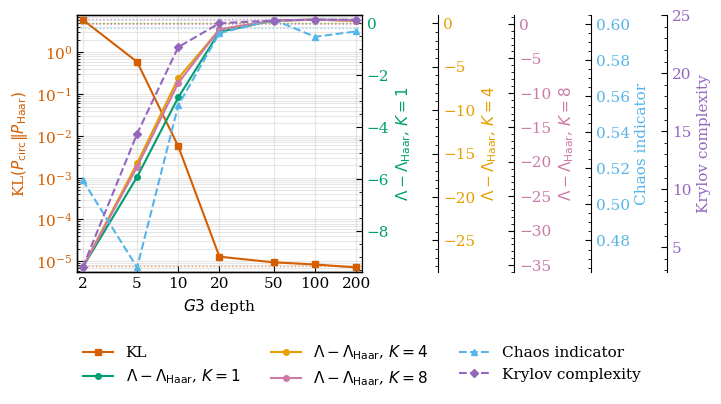

In [35]:
def _param_of(label):
    return int(label.split("d=")[1])


def _family_items(results, family):
    pattern = re.compile(rf"^{re.escape(family)} d=")
    items = [(lab, r) for lab, r in results.items() if pattern.match(lab)]
    return sorted(items, key=lambda kv: _param_of(kv[0]))


def plot_ors_kl_krylov_chaos(results, family="G3", K_VALUES_SMALL=(1, 4, 8),
                             plot_krylov=True, save_stem=None):
    items = _family_items(results, family)
    if not items:
        raise ValueError(f"No entries found for family {family}")

    haar_item = next(((lab, r) for lab, r in results.items() if lab.startswith("Haar")), None)
    xvals       = np.array([_param_of(lab) for lab, _ in items])
    kl_vals     = np.array([r["kl"]     for _, r in items])
    chaos_vals  = np.array([r["chaos"]  for _, r in items])
    krylov_vals = np.array([r["krylov"] for _, r in items])

    # Pull the Okabe–Ito palette from the active prop cycle (set by the blog rcParams).
    palette = plt.rcParams["axes.prop_cycle"].by_key()["color"]

    mm = 1 / 25.4
    fig, ax_kl = plt.subplots(figsize=(170 * mm, 85 * mm))

    kl_color = palette[1]  # orange-ish
    ax_kl.plot(xvals, kl_vals, "s-", color=kl_color, label="KL", zorder=5)
    if haar_item:
        ax_kl.axhline(haar_item[1]["kl"], color=kl_color, ls=":", lw=1, alpha=0.6)
    ax_kl.set_xscale("log")
    ax_kl.set_xticks(xvals)
    ax_kl.get_xaxis().set_major_formatter(ScalarFormatter())
    ax_kl.get_xaxis().set_minor_locator(NullLocator())
    ax_kl.set_yscale("log")
    ax_kl.set_xlabel(rf"${family}$ depth")
    ax_kl.set_ylabel(r"KL$(P_{\mathrm{circ}} \| P_{\mathrm{Haar}})$", color=kl_color)
    ax_kl.tick_params(axis="y", labelcolor=kl_color)
    ax_kl.grid(alpha=0.3, which="both")

    handles, labels = ax_kl.get_legend_handles_labels()
    offset = 0
    for i, K in enumerate(K_VALUES_SMALL):
        lambda_haar = lambda_haar_largeD(D, K)
        color = palette[(i + 2) % len(palette)]
        ax = ax_kl.twinx()
        ax.spines["right"].set_position(("outward", 55 * offset))
        offset += 1
        ors_vals = np.array([r["ors_by_k"][K]["mean"] for _, r in items]) - lambda_haar
        ax.plot(xvals, ors_vals, "o-", color=color,
                label=rf"$\Lambda - \Lambda_{{\mathrm{{Haar}}}}$, $K={K}$")
        if haar_item:
            ax.axhline(0, color=color, ls=":", lw=1, alpha=0.6)
        ax.set_ylabel(rf"$\Lambda - \Lambda_{{\mathrm{{Haar}}}}$, $K={K}$", color=color)
        ax.tick_params(axis="y", labelcolor=color)
        h, l = ax.get_legend_handles_labels()
        handles += h; labels += l

    if plot_krylov:
        # after the K loop, for the chaos/krylov block:
        extra = [
            (chaos_vals,  "^", "Chaos indicator",   "chaos"),
            (krylov_vals, "D", "Krylov complexity", "krylov"),
        ]
        for j, (vals, marker, lbl, key) in enumerate(extra):
            color = palette[(len(K_VALUES_SMALL) + 2 + j) % len(palette)]
            ax = ax_kl.twinx()
            ax.spines["right"].set_position(("outward", 55 * offset))
            offset += 1
            ax.plot(xvals, vals, f"{marker}--", color=color, label=lbl)
            if haar_item and key in haar_item[1]:
                ax.axhline(haar_item[1][key], color=color, ls=":", lw=1, alpha=0.6)
            ax.set_ylabel(lbl, color=color)
            ax.tick_params(axis="y", labelcolor=color)
            h, l = ax.get_legend_handles_labels()
            handles += h; labels += l

    ax_kl.legend(handles, labels,
                 bbox_to_anchor=(1, -0.22), loc="upper center", ncol=3)

    fig.subplots_adjust(right=0.55)   # main axes end at 55%; rest holds the stacked spines

    if save_stem:
        fig.savefig(f"{save_stem}.pgf")
    plt.show()


plot_ors_kl_krylov_chaos(results, save_stem="figures/exp1_KL-ORS-Krylov-chaos")

## Experiment 2: ORS at Scale (`n=20`)

At `n=20` qubits (`D ≈ 10^6`), the KL-divergence approach requires resolving a histogram peak of width `~10^{-6}`, making it statistically impractical. ORS sidesteps this entirely: a single statevector sample suffices to evaluate the top-K order statistics.

We compare two families at `n=20`, `num_gates=1000`:
- **G3**: gates from {CNOT, H, T}, expected to produce near-Haar states at sufficient depth.
- **G1**: Clifford-only gate set {CNOT, H, S}, known to produce stabiliser states that are maximally anti-Haar.

A near-zero gap (λ ≈ λ_Haar) for G3 and a strongly negative gap for G1 confirms ORS discriminates expressivity at a scale where KL has broken down.

In [7]:
nqbits, K_ors, f = 20, 4, 1.0
num_gates = 20 * nqbits
lam_haar = lambda_haar_largeD_noisy(2**nqbits, K_ors, f)
print(f"n={nqbits}  K={K_ors}  lambda_Haar={lam_haar:.3f}\n")

for name in ["G3", "G1"]:
    qrc = QuantumCircQiskit(name, nqbits=nqbits, num_gates=num_gates)
    _, sorted_probs, _ = lorentz_curves_noisy(
        qrc.get_reservoir, nqbits, 1e7, 1, fidelity=f, verbose=True, statevector=True, measurement_basis="Z",
    )
    lam = order_statistics_score_noisy(sorted_probs, 2 ** nqbits, K=K_ors, f = f)[0]
    print(f"{name:4s}  lambda={lam:+12.3f}   gap={lam - lam_haar:+12.3f}")

n=20  K=4  lambda_Haar=26.227



lorentz_curves_noisy: 100%|██████████| 1/1 [00:00<00:00,  2.88it/s]


G3    lambda=     +25.392   gap=      -0.834


lorentz_curves_noisy: 100%|██████████| 1/1 [00:00<00:00,  2.89it/s]

G1    lambda=  -40314.658   gap=  -40340.884


**Interpretation.** G3 scores within sampling noise of the Haar baseline (gap ≈ 0), confirming that a sufficient number of random T gates drives the ensemble to approximate Haar behaviour. G1 produces a strongly negative score (gap ≈ −317 000), reflecting that Clifford circuits generate stabiliser states confined to an exponentially small subspace. The four-order-of-magnitude difference demonstrates that ORS cleanly separates near-Haar from anti-Haar ensembles at qubit counts where KL would require trillions of samples.

In [85]:
def random_local_pauli_basis(nqbits, rng):
    return rng.choice(["X", "Y", "Z"], size=nqbits).tolist()
def get_basis_labels(bases):
    return  np.array([ b if isinstance(b, str) else "".join(b) for b in bases])

rng = np.random.default_rng(1234)

n_list = np.array([6, 10, 12, 16, 20, 25])
fs = np.array([0.5])
K_ors = 4
B_rand = 10

families = np.array(["G1", "G3", "D2_random"])

depth = 30
degree = 10

results = {}

for nqbits in n_list:
    random_bases = [ random_local_pauli_basis(nqbits, rng) for _ in range(B_rand)]
    num_gates = depth * nqbits
    D2_BASES = ["Z", "X", "Y"] + random_bases
    for family in families:
        qrc = QuantumCircQiskit(family, nqbits=nqbits, num_gates=num_gates, degree = degree)
        basis = D2_BASES if family == "D2_random" else ["Z"]
        for f in fs:
            gaps_basis = []
            lams_basis = []
            lam_exact = lambda_haar_largeD_noisy(2**nqbits, K_ors, f)
            for b in basis:
                _, sorted_probs, _ = lorentz_curves_noisy(
                    qrc.get_reservoir, nqbits, 1e7, 1, fidelity=f,  measurement_basis=b, verbose=False, statevector=True)
                lam       = order_statistics_score_noisy(sorted_probs[:, :K_ors], 2**nqbits, K=K_ors, f=f)[0]
                gaps_basis.append(lam - lam_exact)
                lams_basis.append(lam)
            gap = np.mean(gaps_basis)
            lam = np.mean(lams_basis)
            
            results[(family, f, nqbits)] = {'gap': gap, 'lam': lam, 'lam_Haar': lam_exact,
                                            "basis_gaps": np.array(gaps_basis), "basis_lams": np.array(lams_basis), 
                                            "bases": get_basis_labels(basis)}
            print(f"n = {nqbits}, famlily = {family}, f={f:.1f}, gap={lam - lam_exact:+.6f}")

n = 6, famlily = G1, f=0.5, gap=-9.337232
n = 6, famlily = G3, f=0.5, gap=+0.833835
n = 6, famlily = D2_random, f=0.5, gap=-4.118305
n = 10, famlily = G1, f=0.5, gap=-289.226383
n = 10, famlily = G3, f=0.5, gap=+0.717269
n = 10, famlily = D2_random, f=0.5, gap=-76.294646
n = 12, famlily = G1, f=0.5, gap=-1214.335013
n = 12, famlily = G3, f=0.5, gap=-1.374728
n = 12, famlily = D2_random, f=0.5, gap=-300.608035
n = 16, famlily = G1, f=0.5, gap=-19816.169665
n = 16, famlily = G3, f=0.5, gap=-1.267209
n = 16, famlily = D2_random, f=0.5, gap=-4824.177771
n = 20, famlily = G1, f=0.5, gap=-40340.884458
n = 20, famlily = G3, f=0.5, gap=+0.377325
n = 20, famlily = D2_random, f=0.5, gap=-77093.401785
n = 25, famlily = G1, f=0.5, gap=-1292171.339493
n = 25, famlily = G3, f=0.5, gap=+0.875254
n = 25, famlily = D2_random, f=0.5, gap=-2466493.943938


## Experiment 3: Noisy ORS Statistic

Hardware circuits are affected by gate errors and readout noise. We model this via a **global depolarising fidelity** `f ∈ [0, 1]`, where `f=1` is noiseless and `f→0` sends every state toward the maximally mixed state.

The Haar log-likelihood is replaced by a noise-adapted version `log P_k^noisy(p_{(k)}, f)`, and the Haar baseline shifts to `λ_Haar_noisy(f)` (implemented in `lambda_haar_largeD_noisy`). The **ORS gap** `λ − λ_Haar_noisy(f)` remains a valid expressivity measure: a gap near zero means the circuit matches the noise level of a Haar-random circuit at fidelity `f`.

Below we verify that a G3 circuit (1000 gates, `n=6`) tracks the noisy Haar baseline across `f ∈ [0.1, 1.0]`, confirming internal consistency of the noise model. Hardware results are in `Exp - Quantum Hardware.ipynb`.

In [8]:
nqbits, num_gates, K_ors = 6, 1000, 4
fs = [1.0, 0.9, 0.8, 0.7, 0.6, 0.5, 0.4, 0.3, 0.2, 0.1]

qrc = QuantumCircQiskit('G3', nqbits=nqbits, num_gates=num_gates)
for f in fs:
    _, sorted_probs, _ = lorentz_curves_noisy(
        qrc.get_reservoir, nqbits, 1e7, 1, fidelity=f, verbose=False, statevector=True
    )
    lam       = order_statistics_score_noisy(sorted_probs, 2**nqbits, K=K_ors, f=f)[0]
    lam_exact = lambda_haar_largeD_noisy(2**nqbits, K_ors, f)
    print(f"f={f:.1f}  lambda={lam:.6f}  lambda_Haar(f)={lam_exact:.6f}  gap={lam - lam_exact:+.6f}")

f=1.0  lambda=6.979086  lambda_Haar(f)=5.975389  gap=+1.003696
f=0.9  lambda=7.198587  lambda_Haar(f)=6.194890  gap=+1.003696
f=0.8  lambda=7.443968  lambda_Haar(f)=6.440272  gap=+1.003696
f=0.7  lambda=7.722158  lambda_Haar(f)=6.718462  gap=+1.003696
f=0.6  lambda=8.043306  lambda_Haar(f)=7.039609  gap=+1.003696
f=0.5  lambda=8.423142  lambda_Haar(f)=7.419446  gap=+1.003696
f=0.4  lambda=8.888025  lambda_Haar(f)=7.884328  gap=+1.003696
f=0.3  lambda=9.487362  lambda_Haar(f)=8.483666  gap=+1.003696
f=0.2  lambda=10.332081  lambda_Haar(f)=9.328385  gap=+1.003696
f=0.1  lambda=11.776138  lambda_Haar(f)=10.772441  gap=+1.003696


## Experiment 4: Multibasis Noisy ORS

ORS depends on measuring the output state in a fixed computational basis. If that basis happens to be aligned with the circuit's structure, the score can be artificially inflated or deflated. Averaging over multiple measurement bases gives a more robust expressivity estimate.

**Setup**
- Results are loaded from `results/ors/noisy_basis/`, generated by `experiments/ORS/run_ORS_noisy_multibasis.py`.
- Each file stores, for every (n, K, f) combination, the **ORS gap** (λ − λ_Haar_noisy) evaluated in each of 53 measurement bases: 3 fixed canonical bases (Z, X, Y) followed by 50 random local Pauli bases.
- The key format is `gap_n{n}_K{K}_f{ftag}` (e.g. `gap_n10_K4_f0p50`), with shape `(53,)`.
- `B` controls how many of the first bases are used to compute the mean and std of the gap. With `B=5`, this uses Z, X, Y plus 2 random bases.
- Both **D2 families** (degree sweep) and **G families** (gate-count sweep) are loaded from the same directory. G-family files are produced by the same script with `--gates-name G1/G2/G3`; if not yet available, those panels will be empty.

Three plots are shown, one per qubit count `n ∈ {10, 8, 6}`.

In [9]:
B = 5  # number of Pauli bases for mean/std (first B from the file: Z, X, Y, rand1, rand2, ...)

RESULTS_MB  = 'results/ors/noisy_basis/'
G_FAMILIES  = ['G1', 'G2', 'G3']
D2_FAMILIES = ['D2_random', 'D2_random_XZ', 'D2_random_XZY']
G_NUM_GATES = [10, 20, 50, 100, 200, 1000]
D2_DEGREES  = [1, 2, 4, 6, 8, 10]
K_MB   = 4
F_PLOT = 1.0
NS = 100

COLORS = {
    'G1': '#1f77b4', 'G2': '#2ca02c', 'G3': '#d62728',
    'D2_random': '#9467bd', 'D2_random_XZ': '#e377c2', 'D2_random_XZY': '#ff7f0e',
}
MARKERS = {
    'G1': 's', 'G2': 'D', 'G3': '^',
    'D2_random': 'v', 'D2_random_XZ': 'P', 'D2_random_XZY': 'X',
}


def _ftag(f):
    return f"{f:.2f}".replace('.', 'p')


def _mb_path(fam, val, kind):
    suffix = f"_ng{val}" if kind == 'ng' else f"_deg{val}_L1"
    return os.path.join(RESULTS_MB, f"{fam}{suffix}_{NS}runs_seed1234_basis4321_noise_multibasis.npz")


def load_gap(fam, val, n, f, K, kind):
    path = _mb_path(fam, val, kind)
    if not os.path.exists(path):
        return np.nan, np.nan
    data = np.load(path)
    key = f"gap_n{n}_K{K}_f{_ftag(f)}"
    if key not in data.files:
        print('Key not found: ', key, ' in file: ', path)
        return np.nan, np.nan
    gap = data[key][:B]
    return gap.mean(), gap.std()/B


def collect(fam, xs, n, f, K, kind):
    pairs = [load_gap(fam, x, n, f, K, kind) for x in xs]
    return np.array([p[0] for p in pairs]), np.array([p[1] for p in pairs])

In [20]:
def plot_multibasis(n, f=F_PLOT, K=K_MB, ors_floor=-1000, calculate_lambda_exact = False):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    specs = [
        (axes[0], 'G-families',  G_FAMILIES,  G_NUM_GATES, 'Number of gates', 'ng'),
        (axes[1], 'D2-families', D2_FAMILIES, D2_DEGREES,  'Degree',          'deg'),
    ]
    for ax, title, fams, xs, xlabel, kind in specs:
        ax.axhline(0, color='gray', ls='--', lw=1.2, alpha=0.55, label='Haar')
        for fam in fams:
            y, e = collect(fam, xs, n, f, K, kind)
            
            valid = np.isfinite(y)
            if not valid.any():
                continue
            if calculate_lambda_exact:
                lambda_approx = lambda_haar_largeD(2**n, K)
                lambda_exact = lambda_haar_exact(2**n, K)
                y = y + lambda_approx - lambda_exact
            y_plot = np.clip(np.where(valid, y, ors_floor), ors_floor, None)
            ax.plot(np.array(xs), y_plot, marker=MARKERS[fam], color=COLORS[fam], lw=2, label=fam)
            ax.fill_between(np.array(xs)[valid],
                            y[valid] - e[valid], y[valid] + e[valid],
                            color=COLORS[fam], alpha=0.15)
        ax.set_xscale('log')
        ax.set_xticks(xs)
        ax.get_xaxis().set_major_formatter(plt.ScalarFormatter())
        ax.get_xaxis().set_minor_locator(plt.NullLocator())
        ax.set_xlabel(xlabel, fontsize=13)
        ax.set_title(title, fontsize=13)
        ax.grid(True, which='both', alpha=0.3)

    axes[0].set_ylabel(r'$\Lambda - \Lambda_{\rm Haar}$', fontsize=13)

    seen = {}
    for ax in axes:
        for h, l in zip(*ax.get_legend_handles_labels()):
            seen.setdefault(l, h)
    fig.legend(seen.values(), seen.keys(), loc='upper center',
               bbox_to_anchor=(0.5, -0.02), ncol=len(seen), fontsize=12, frameon=False)
    fig.suptitle(f'Multibasis ORS gap  (n={n}, f={f}, K={K}, B={B})', fontsize=14)
    fig.tight_layout()
    plt.show()

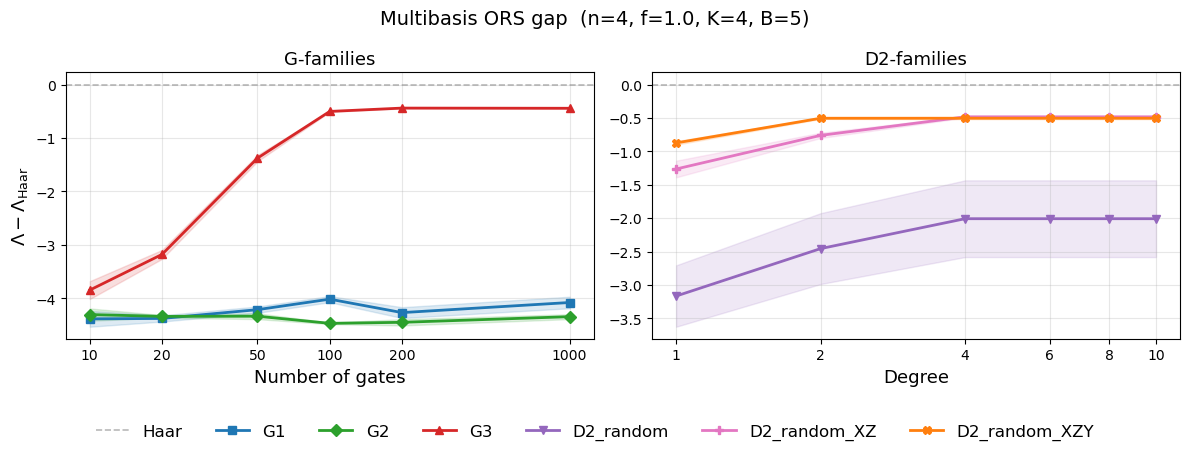

In [22]:
plot_multibasis(n=4, ors_floor=-10, calculate_lambda_exact=True)

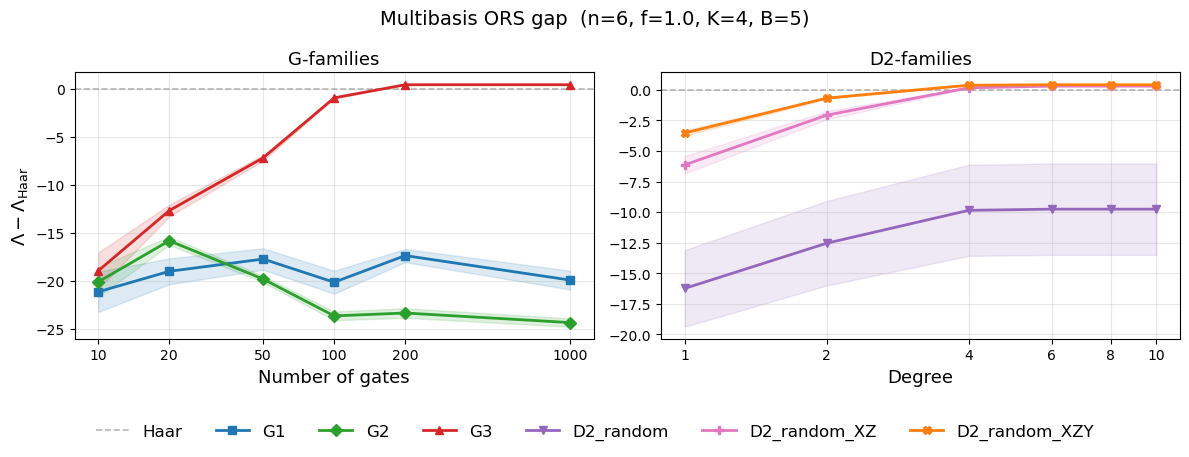

In [79]:
plot_multibasis(n=6, ors_floor=-50)

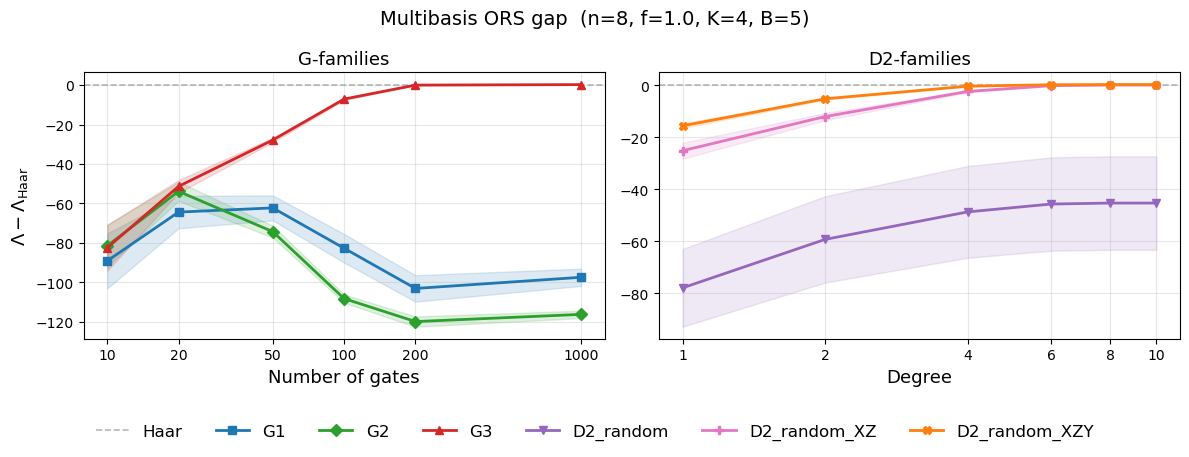

In [80]:
plot_multibasis(n=8, ors_floor=-120)

Key not found:  gap_n10_K4_f1p00  in file:  results/ors/noisy_basis/G1_ng1000_100runs_seed1234_basis4321_noise_multibasis.npz
Key not found:  gap_n10_K4_f1p00  in file:  results/ors/noisy_basis/G3_ng1000_100runs_seed1234_basis4321_noise_multibasis.npz
Key not found:  gap_n10_K4_f1p00  in file:  results/ors/noisy_basis/D2_random_XZY_deg10_L1_100runs_seed1234_basis4321_noise_multibasis.npz


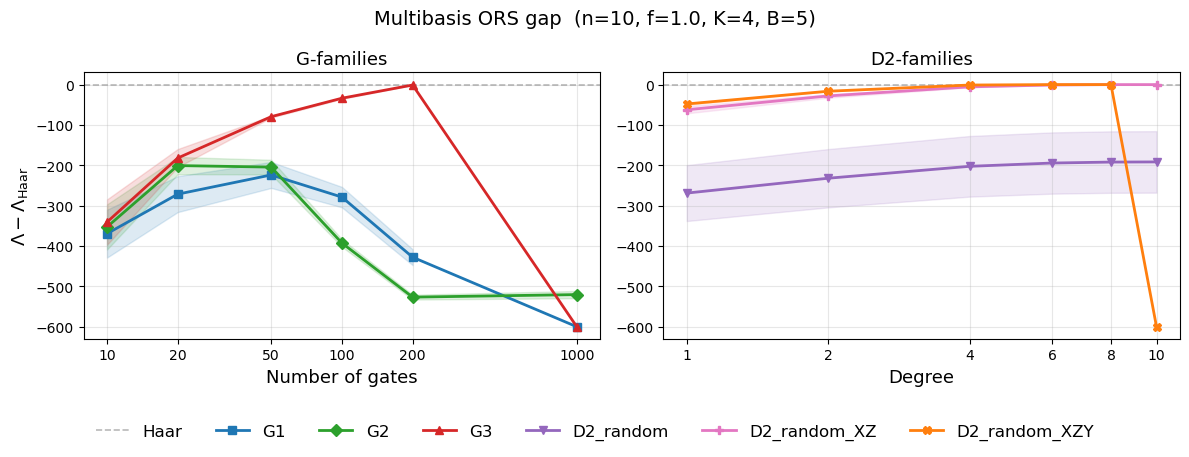

In [95]:
plot_multibasis(n=10, f=1.0, ors_floor=-600)